## Hücre 1 -- Gerekli Kütüphaneler

In [1]:
# Veri işleme
import pandas as pd
import numpy as np

# Veri görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Makine Öğrenmesi
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Başarı metrikleri
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Model kaydetme
import joblib

## Hücre 2 -- Veri Setini Oku

In [2]:
# veri setini okuma
df = pd.read_csv("real_dataset.csv")

df.head()

,type,url,tags,text,createdAt,location,authorUserName,university
0,tweet,https://x.com/denizcosta96/status/198568993385...,0,@lleidenschaftt Hiç gitmedim de çok kötü duruy...,Tue Nov 04 12:45:47 +0000 2025,NaN,denizcosta96,YTU
1,tweet,https://x.com/huntsmanlll/status/1987156151520...,0,@orientalmartyr @zoonpolitikion savunma sanayi...,Sat Nov 08 13:52:00 +0000 2025,NaN,huntsmanlll,YTU
2,tweet,https://x.com/dacikgocuk32/status/198715316749...,1,Ytü eski kütüphane şuan goated durumdaymış gib...,Sat Nov 08 13:40:09 +0000 2025,NaN,dacikgocuk32,YTU
3,tweet,https://x.com/9smajlovic/status/19865078169499...,0,yarın ytü kütüphane olacagim ins tavani cökmez,Thu Nov 06 18:55:45 +0000 2025,boun 20,9smajlovic,YTU
4,tweet,https://x.com/bugrahanyldrmm/status/1986787950...,0,1A'daki tadilatı bitirin de kütüphaneye gerçek...,Fri Nov 07 13:28:54 +0000 2025,odtü,bugrahanyldrmm,ODTU


## Hücre 3 -- Veri Setinin Boyutu

In [3]:
print(f"Satır sayısı = {df.shape[0]}")
print(f"Sütun sayısı = {df.shape[1]}")

Satır sayısı = 11020
Sütun sayısı = 8


## Hücre 4 -- Veri Setini Tanıma

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   type            11020 non-null  str  
 1   url             11020 non-null  str  
 2   tags            11020 non-null  int64
 3   text            11020 non-null  str  
 4   createdAt       11020 non-null  str  
 5   location        5992 non-null   str  
 6   authorUserName  11020 non-null  str  
 7   university      11020 non-null  str  
dtypes: int64(1), str(7)
memory usage: 688.9 KB


## Hücre 5 -- Sütun İsimlerl

In [5]:
df.columns

Index(['type', 'url', 'tags', 'text', 'createdAt', 'location',
       'authorUserName', 'university'],
      dtype='str')

## Hücre 6 -- İlk Birkaç Yorumu

In [6]:
df["text"].head(10)

0    @lleidenschaftt Hiç gitmedim de çok kötü duruy...
1    @orientalmartyr @zoonpolitikion savunma sanayi...
2    Ytü eski kütüphane şuan goated durumdaymış gib...
3       yarın ytü kütüphane olacagim ins tavani cökmez
4    1A'daki tadilatı bitirin de kütüphaneye gerçek...
5    Uzun zaman sonra ODTÜ'ye gittim ve güvenlik ka...
6    odtü, boun, itü, koç ve sabancı harici bir üni...
7    @LAB_Comics Yok hiçbir itü ürünü tüketmiyorum ...
8    itü 6. hafta 3 vize işi beni yordu babacım htt...
9    Gölet yurdunda köprüyü gören bir seyir yeri va...
Name: text, dtype: str

## Hücre 7 -- Etiketler

In [7]:
df["tags"].value_counts()

tags
0    8251
1    2769
Name: count, dtype: int64

In [8]:
df["tags"].value_counts(normalize = True) * 100

tags
0    74.872958
1    25.127042
Name: proportion, dtype: float64

## Hücre 8 -- Eksik Veri

In [9]:
df.isnull().sum()

type                 0
url                  0
tags                 0
text                 0
createdAt            0
location          5028
authorUserName       0
university           0
dtype: int64

## Hücre 9 -- İstatistiksel Özet

In [10]:
df.describe(include = "all")

,type,url,tags,text,createdAt,location,authorUserName,university
count,11020,11020,11020.000000,11020,11020,5992,11020,11020
unique,1,11007,NaN,11020,10997,1891,8598,14
top,tweet,https://x.com/simgekurkcu/status/1323391105795...,NaN,@lleidenschaftt Hiç gitmedim de çok kötü duruy...,Mon Nov 02 22:26:41 +0000 2020,"İstanbul, Türkiye",kanaxxaqua,HACETTEPE
freq,11020,3,NaN,1,3,627,36,2352
mean,NaN,NaN,0.251270,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.433763,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN


## Hücre 10 -- Kullanacağımız Sütunlar

In [11]:
df_model = df[["text", "tags"]].copy()

df_model.head()

,text,tags
0,@lleidenschaftt Hiç gitmedim de çok kötü duruy...,0
1,@orientalmartyr @zoonpolitikion savunma sanayi...,0
2,Ytü eski kütüphane şuan goated durumdaymış gib...,1
3,yarın ytü kütüphane olacagim ins tavani cökmez,0
4,1A'daki tadilatı bitirin de kütüphaneye gerçek...,0


## Hücre 11 -- Metinleri İnceleme

In [12]:
# rastgele 10 yorum 

for i, yorum in enumerate(df_model["text"].sample(10, random_state= 42), start = 1):
    print(f"{i}. {yorum}\n")

1. ders secim baslangiciyla donem baslangici ayni gun kesin kayit olmadik ki kafadan bir hafta daha tatil tesekkurler ege uni

2. Böyle sistem gerçekten olmaz olsun! Sınavda bir şey yokken 2 kere sistemden atıldım hocamız bir şey yapamıyor,öğrenci işleri zaten telefon açmaya tenezzül etmiyor,bir sorudan diğerine 10 dakika da geçtim ! #deü #DeüSınıftaKaldı
@9euiibf

3. ytü denen okul diğer okullarla aynı anda başlayıp neden 3 hafta geç bitiyorsun ne boktan şeysin sen

4. Team Kayyum tarihe geçiyor! Onurlarına ve cesaretlerine haset, garez ve kin ile baktığınız hocalarımızın iradesini utanılacak ayak oyunlarıyla yalanlayıp, biricik Boğaziçi'mize gelmiş geçmiş en kötü günlerini yaşatarak! Yazıklar olsun! #KabulEtmiyoruzVazgecmiyoruz @melihbulu

5. ilk sınav notlarını ikinci sınavdan önce açıklayacağız demişlerdi, sınava 1 saat kala açıkladılar
ODTÜ KİMYA KAPATILSIN💖

6. ODTÜ Rektörlüğü her yıl Devrim Stadı’nda yapılan mezuniyet törenini güvenlik önlemi bahanesiyle kültür merkezine almış.


## Hücre 12 -- Metin Temizleme

In [13]:
import re

def metin_temizle(metin):
    # Metni string'e çevir
    metin = str(metin)

    # URL'leri kaldır
    metin = re.sub(r"https?://\S+|www\.\S+", " ", metin)

    # @kullanici mentionlarını kaldır
    metin = re.sub(r"@\w+", " ", metin)

    # Hashtag işaretini kaldır fakat kelimeyi koru
    # #DeüSınıftaKaldı -> DeüSınıftaKaldı
    metin = re.sub(r"#(\w+)", r"\1", metin)

    # Fazla boşlukları ve satır sonlarını temizle
    metin = re.sub(r"\s+", " ", metin).strip()

    return metin

## Hücre 13 -- Temizleme İşlemi

In [14]:
df_model["clean_text"] = df_model["text"].apply(metin_temizle)

df_model[["text", "clean_text", "tags"]].head(10)

,text,clean_text,tags
0,@lleidenschaftt Hiç gitmedim de çok kötü duruy...,Hiç gitmedim de çok kötü duruyo ytü,0
1,@orientalmartyr @zoonpolitikion savunma sanayi...,savunma sanayi firmasında staj yaptıgım donem ...,0
2,Ytü eski kütüphane şuan goated durumdaymış gib...,Ytü eski kütüphane şuan goated durumdaymış gib...,1
3,yarın ytü kütüphane olacagim ins tavani cökmez,yarın ytü kütüphane olacagim ins tavani cökmez,0
4,1A'daki tadilatı bitirin de kütüphaneye gerçek...,1A'daki tadilatı bitirin de kütüphaneye gerçek...,0
5,Uzun zaman sonra ODTÜ'ye gittim ve güvenlik ka...,Uzun zaman sonra ODTÜ'ye gittim ve güvenlik ka...,0
6,"odtü, boun, itü, koç ve sabancı harici bir üni...","odtü, boun, itü, koç ve sabancı harici bir üni...",1
7,@LAB_Comics Yok hiçbir itü ürünü tüketmiyorum ...,Yok hiçbir itü ürünü tüketmiyorum teşekkürler,0
8,itü 6. hafta 3 vize işi beni yordu babacım htt...,itü 6. hafta 3 vize işi beni yordu babacım,0
9,Gölet yurdunda köprüyü gören bir seyir yeri va...,Gölet yurdunda köprüyü gören bir seyir yeri va...,1


## Hücre 14 -- Tekrar Eden Veriler

In [15]:
print("Toplam kayıt sayısı :", len(df_model))

print("Tekrar eden yorum sayısı :", df_model["clean_text"].duplicated().sum())

Toplam kayıt sayısı : 11020
Tekrar eden yorum sayısı : 6


## Hücre 15 -- Tekrar Eden Verileri Silme

In [16]:
df_model = df_model.drop_duplicates(subset="clean_text").reset_index(drop=True)

print("Yeni kayıt sayısı :", len(df_model))

Yeni kayıt sayısı : 11014


## ML 1 — Bağımsız ve Bağımlı Değişkenlerin Oluşturulması

In [17]:
# Bağımsız değişken (yorumlar)
X = df_model["clean_text"]

# Bağımlı değişken (etiketler)
y = df_model["tags"]

print("X Boyutu :", X.shape)
print("y Boyutu :", y.shape)

print("\nİlk yorum:")
print(X.iloc[0])

print("\nİlk etiket:")
print(y.iloc[0])

X Boyutu : (11014,)
y Boyutu : (11014,)

İlk yorum:
Hiç gitmedim de çok kötü duruyo ytü

İlk etiket:
0


## ML 2 — Eğitim ve Test Verisinin Ayrılması

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# Veriyi eğitim ve test olarak ayır

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Eğitim veri sayısı :", len(X_train))
print("Test veri sayısı   :", len(X_test))

Eğitim veri sayısı : 8811
Test veri sayısı   : 2203


## ML 3 — TF-IDF ile Metinleri Sayısallaştırma

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    max_features=10000
)

In [24]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [25]:
print("Eğitim veri boyutu :", X_train_tfidf.shape)
print("Test veri boyutu   :", X_test_tfidf.shape)

Eğitim veri boyutu : (8811, 10000)
Test veri boyutu   : (2203, 10000)


## ML 4 — Logistic Regression Modeli

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [27]:
logistic_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [28]:
y_pred_lr = logistic_model.predict(X_test_tfidf)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy: %{accuracy * 100:.2f}")

Accuracy: %88.11


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.98      0.92      1649
           1       0.89      0.60      0.72       554

    accuracy                           0.88      2203
   macro avg       0.89      0.79      0.82      2203
weighted avg       0.88      0.88      0.87      2203



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[1609   40]
 [ 222  332]]


## ML 5 — Linear SVM Modeli

In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

In [33]:
svm_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [34]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_svm)

print(f"Accuracy: %{accuracy*100:.2f}")

Accuracy: %90.06


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1649
           1       0.85      0.73      0.79       554

    accuracy                           0.90      2203
   macro avg       0.88      0.84      0.86      2203
weighted avg       0.90      0.90      0.90      2203



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

print(cm)

[[1579   70]
 [ 149  405]]


## ML 6 — Multinomial Naive Bayes

In [38]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

In [39]:
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[6596.,2215.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.29,-1.38]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 10000)","[[6.58,2.05,0.95,...,0. ,4.87,0.49], [2.42,0.48,0. ,...,0.88,1.61,0.24]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 10000)","[[ -8.4 , -9.31, -9.75,...,-10.42, -8.65,-10.03], [ -8.57, -9.41, -9.8 ,..., -9.17, -8.85, -9.59]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [40]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [41]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Accuracy: %{accuracy * 100:.2f}")

Accuracy: %83.39


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1649
           1       0.97      0.35      0.52       554

    accuracy                           0.83      2203
   macro avg       0.89      0.67      0.71      2203
weighted avg       0.86      0.83      0.80      2203



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

[[1642    7]
 [ 359  195]]


## ML 7 — Modellerin Karşılaştırılması

In [44]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [45]:
sonuclar = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Multinomial Naive Bayes"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ]
})

In [46]:
sonuclar["Accuracy"] = sonuclar["Accuracy"] * 100

In [47]:
sonuclar = sonuclar.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

In [48]:
sonuclar = sonuclar.round(2)

In [49]:
sonuclar

,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,90.06,0.85,0.73,0.79
1,Logistic Regression,88.11,0.89,0.60,0.72
2,Multinomial Naive Bayes,83.39,0.97,0.35,0.52


In [51]:
sonuclar.style\
    .highlight_max(subset=["Accuracy"], color="lightgreen")\
    .highlight_max(subset=["Precision"], color="lightblue")\
    .highlight_max(subset=["Recall"], color="khaki")\
    .highlight_max(subset=["F1-Score"], color="lightcoral")\
    .format({
        "Accuracy": "%{:.2f}",
        "Precision": "{:.2f}",
        "Recall": "{:.2f}",
        "F1-Score": "{:.2f}"
    })

,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,%90.06,0.85,0.73,0.79
1,Logistic Regression,%88.11,0.89,0.60,0.72
2,Multinomial Naive Bayes,%83.39,0.97,0.35,0.52


### Sonuç

Üç farklı makine öğrenmesi algoritması karşılaştırılmıştır.

- Linear SVM modeli %90.06 doğruluk oranı ile en başarılı model olmuştur.
- Logistic Regression modeli %88.11 doğruluk sağlamıştır.
- Multinomial Naive Bayes modeli %83.39 doğruluk oranı ile diğer modellere göre daha düşük performans göstermiştir.

Bu nedenle projenin yapay zekâ modülünde **Linear SVM** modeli kullanılacaktır.

## Confusion Matrix (Heatmap)

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

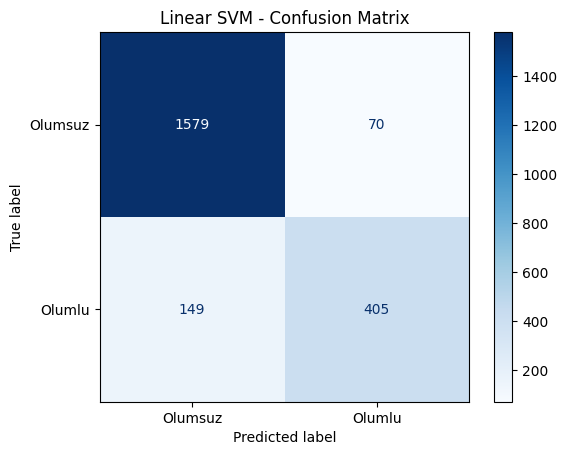

In [53]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=["Olumsuz", "Olumlu"],
    cmap="Blues",
    values_format="d"
)

plt.title("Linear SVM - Confusion Matrix")
plt.show()

## ML 9 — Model ve TF-IDF'yi Kaydetme

In [54]:
import joblib

In [55]:
# Linear SVM modelini kaydet
joblib.dump(svm_model, "sentiment_model.pkl")

# TF-IDF Vectorizer'ı kaydet
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("✅ Model başarıyla kaydedildi.")
print("✅ TF-IDF Vectorizer başarıyla kaydedildi.")

✅ Model başarıyla kaydedildi.
✅ TF-IDF Vectorizer başarıyla kaydedildi.


## ML 10 — Kaydedilen Modeli Yükleme

In [56]:
import joblib

In [57]:
# Kaydedilen modeli ve TF-IDF vektörleştiricisini yükle

loaded_model = joblib.load("sentiment_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("✅ Sentiment modeli başarıyla yüklendi.")
print("✅ TF-IDF Vectorizer başarıyla yüklendi.")

✅ Sentiment modeli başarıyla yüklendi.
✅ TF-IDF Vectorizer başarıyla yüklendi.


In [58]:
print(type(loaded_model))
print(type(loaded_tfidf))

<class 'sklearn.svm._classes.LinearSVC'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


## ML 11 — Yeni Yorumlarla Modeli Test Etme

In [59]:
# Test etmek istediğimiz yeni yorumlar

yorumlar = [
    "Kütüphane hizmetlerinden çok memnunum.",
    "Yemekhane yemekleri çok kötü.",
    "OBS sistemi sürekli çöküyor.",
    "Hocalar çok ilgili ve yardımsever.",
    "Ders programı çok düzensiz hazırlanmış.",
    "Kampüs ortamını gerçekten çok seviyorum.",
    "Öğrenci işleri telefonlara hiç bakmıyor.",
    "Laboratuvar imkanları oldukça başarılı.",
    "Sınav sistemi tam bir rezalet.",
    "Üniversitemde okumaktan gurur duyuyorum."
]

In [60]:
# Yorumları TF-IDF ile sayısallaştır

yorumlar_tfidf = loaded_tfidf.transform(yorumlar)

# Tahminleri al

tahminler = loaded_model.predict(yorumlar_tfidf)

In [61]:
# Sonuçları yazdır

for yorum, tahmin in zip(yorumlar, tahminler):

    if tahmin == 1:
        etiket = "🟢 Olumlu"

    else:
        etiket = "🔴 Olumsuz"

    print(f"Yorum : {yorum}")
    print(f"Tahmin: {etiket}")
    print("-" * 60)

Yorum : Kütüphane hizmetlerinden çok memnunum.
Tahmin: 🟢 Olumlu
------------------------------------------------------------
Yorum : Yemekhane yemekleri çok kötü.
Tahmin: 🔴 Olumsuz
------------------------------------------------------------
Yorum : OBS sistemi sürekli çöküyor.
Tahmin: 🔴 Olumsuz
------------------------------------------------------------
Yorum : Hocalar çok ilgili ve yardımsever.
Tahmin: 🔴 Olumsuz
------------------------------------------------------------
Yorum : Ders programı çok düzensiz hazırlanmış.
Tahmin: 🔴 Olumsuz
------------------------------------------------------------
Yorum : Kampüs ortamını gerçekten çok seviyorum.
Tahmin: 🟢 Olumlu
------------------------------------------------------------
Yorum : Öğrenci işleri telefonlara hiç bakmıyor.
Tahmin: 🔴 Olumsuz
------------------------------------------------------------
Yorum : Laboratuvar imkanları oldukça başarılı.
Tahmin: 🔴 Olumsuz
------------------------------------------------------------
Yorum : Sın

## ML 12 — Sonuç ve Değerlendirme

Bu çalışmada Türkçe üniversite yorumlarından oluşan veri seti kullanılarak duygu analizi modeli geliştirilmiştir. Veri ön işleme aşamasında metinler temizlenmiş, tekrar eden kayıtlar kaldırılmış ve TF-IDF yöntemi ile metinler sayısal vektörlere dönüştürülmüştür.
Model geliştirme aşamasında Logistic Regression, Linear SVM ve Multinomial Naive Bayes algoritmaları karşılaştırılmıştır. Yapılan testler sonucunda en yüksek başarıyı %90.06 doğruluk oranı ile Linear SVM modeli elde etmiştir. Ayrıca Linear SVM modeli pozitif sınıf için diğer modellere göre daha dengeli Recall ve F1-Score değerleri göstermiştir.
Bu nedenle projenin duygu analizi modülünde kullanılmak üzere Linear SVM modeli seçilmiş, model ile birlikte TF-IDF vektörleştiricisi .pkl formatında kaydedilmiştir. Yeni yorumlar üzerinde yapılan denemelerde modelin genel olarak başarılı tahminler ürettiği görülmüştür.
Bir sonraki aşamada kaydedilen model ve TF-IDF vektörleştiricisi FastAPI backend sistemine entegre edilerek kullanıcıların oluşturduğu geri bildirimlerin otomatik olarak olumlu veya olumsuz şeklinde sınıflandırılması sağlanacaktır.